# Dataset 1

## Load Data and Preprocessing

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
path = r'/content/drive/MyDrive/CVR College/Mini Project/notebooksV3/rail_delay_cleaned.parquet'
# 1. Load the cleaned dataset
df = pd.read_parquet(path)

# 2. Define Features (X) and Target (y)
target_col = 'arrival_delay_time'
feature_cols = [
    'teu_count', 'train_length [m]', 'total_distance_trip [km]',
    'departure_delay_time [min]', 'distance_between_stations [km]',
    'weight_per_length [t/m]', 'weight_per_wagon [t/wagon]'
]

X = df[feature_cols]
y = df[target_col]

# 3. Train-Test Split (70% training, 30% testing) [cite: 174]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 4. Z-score Standardization [cite: 161]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Helper function to print evaluation metrics
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} Performance ---")
    print(f"R2 Score: {r2_score(y_true, y_pred):.3f}")
    print(f"RMSE:     {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}")
    print(f"MAE:      {mean_absolute_error(y_true, y_pred):.3f}")
    print(f"MAPE:     {mean_absolute_percentage_error(y_true, y_pred):.3f}\n")

## Build Models (LR, KNN, RF)

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# --- 1. Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, lr_preds)

# --- 2. K-Nearest Neighbors (KNN) ---
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)
evaluate_model("K-Nearest Neighbors", y_test, knn_preds)

# --- 3. Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, rf_preds)

--- Linear Regression Performance ---
R2 Score: 0.166
RMSE:     25.906
MAE:      23.093
MAPE:     52922095261833784.000

--- K-Nearest Neighbors Performance ---
R2 Score: 0.807
RMSE:     12.473
MAE:      4.755
MAPE:     6362174404225655.000

--- Random Forest Performance ---
R2 Score: 0.871
RMSE:     10.177
MAE:      3.349
MAPE:     6549804044037910.000



## LGBM

Tuning LightGBM with Random Search (this might take a minute)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 993
[LightGBM] [Info] Number of data points in the train set: 26740, number of used features: 7
[LightGBM] [Info] Start training from score 27.091399
Best Parameters found: {'subsample': 1.0, 'num_leaves': 100, 'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

--- Tuned LightGBM Performance ---
R2 Score: 0.877
RMSE:     9.968
MAE:      3.772
MAPE:     7038405029389084.000

Generating SHAP Feature Importance...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


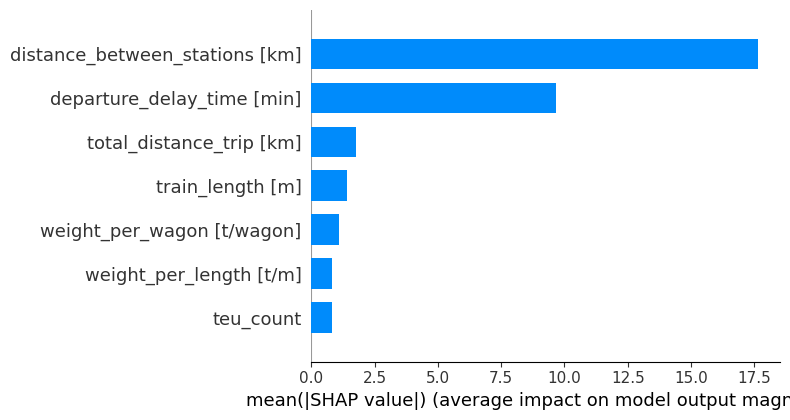

In [3]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
import shap
import matplotlib.pyplot as plt

# 1. Initialize the Base LightGBM Model
lgbm_base = lgb.LGBMRegressor(random_state=42, n_jobs=-1)

# 2. Define the Hyperparameter Grid for Random Search
# The paper tuned these parameters to optimize performance
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 50, 100],
    'max_depth': [-1, 10, 20],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 3. Perform Random Search with 5-Fold Cross Validation
print("Tuning LightGBM with Random Search (this might take a minute)...")
lgbm_random = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_grid,
    n_iter=15,          # Number of parameter settings that are sampled
    cv=5,               # 5-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Fit the random search model
lgbm_random.fit(X_train_scaled, y_train)

# 4. Get the Best Model and Predict
best_lgbm = lgbm_random.best_estimator_
print(f"Best Parameters found: {lgbm_random.best_params_}\n")

lgbm_preds = best_lgbm.predict(X_test_scaled)
evaluate_model("Tuned LightGBM", y_test, lgbm_preds)

# ==========================================
# STEP 5: SHAP Interpretability Layer
# ==========================================
# This matches the paper's methodology for explaining the predictions
print("Generating SHAP Feature Importance...")

# SHAP expects a DataFrame to keep feature names, so we convert the scaled array back
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test_scaled_df)

# Plot the Summary Plot (This will look similar to Figure 6 in the paper)
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar")

## LSTM

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Reshape data for LSTM [samples, time steps, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# 2. Build the LSTM Architecture
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2), # Dropout to prevent overfitting
    Dense(32, activation='relu'),
    Dense(1)      # Output layer for regression (predicting arrival delay)
])

# 3. Compile the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# 4. Train the model
print("Training LSTM...")
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# 5. Predict and Evaluate
lstm_preds = lstm_model.predict(X_test_lstm).flatten()
evaluate_model("LSTM", y_test, lstm_preds)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM...
Epoch 1/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 726.1753 - val_loss: 466.0437
Epoch 2/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 464.3956 - val_loss: 407.8078
Epoch 3/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 381.0266 - val_loss: 298.2778
Epoch 4/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 285.2404 - val_loss: 230.4520
Epoch 5/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 231.9112 - val_loss: 196.7976
Epoch 6/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 210.1103 - val_loss: 187.6156
Epoch 7/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 198.6590 - val_loss: 184.5268
Epoch 8/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 190.3971 - val_loss: 172.2463
Epoch 9/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 184.9134 - val_loss: 169.5505
Epoch 10/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 181.6448 - val_loss: 166.6215
Epoch 11/20
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 177.8433 - val_loss: 



| Model | R2 Score | RMSE | MAE | MAPE |
| --- | --- | --- | --- | --- |
| **LR** | 0.166 | 25.906 | 23.093 | 52922095261833768.000 |
| **KNN** | 0.807 | 12.473 | 4.755 | 6362174404225655.000 |
| **RF** | 0.871 | 10.177 | 3.349 | 6549804044037910.000 |
| **LGBM** | 0.877 | 9.968 | 3.772 | 7038405029389084.000 |
| **LSTM** | 0.818 | 12.120 | 6.205 | 10926099374538752.000 |


# Dataset 2

In [5]:
df.arrival_delay_time.value_counts()

,count
arrival_delay_time,
0,18641
60,14472
30,4029
15,396
63,187
5,182
25,143
120,123
90,28


In [6]:
df = df[df['arrival_delay_time'] > 0]
df.arrival_delay_time.value_counts()

,count
arrival_delay_time,
60,14472
30,4029
15,396
63,187
5,182
25,143
120,123
90,28


In [7]:
df.to_parquet('rail_delay_cleaned_2.parquet')

In [8]:
df.shape

(19560, 11)

## Preprocess Data

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# 2. Define Features (X) and Target (y)
target_col = 'arrival_delay_time'
feature_cols = [
    'teu_count', 'train_length [m]', 'total_distance_trip [km]',
    'departure_delay_time [min]', 'distance_between_stations [km]',
    'weight_per_length [t/m]', 'weight_per_wagon [t/wagon]'
]

X = df[feature_cols]
y = df[target_col]

# 3. Train-Test Split (70% training, 30% testing) [cite: 174]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 4. Z-score Standardization [cite: 161]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Helper function to print evaluation metrics
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} Performance ---")
    print(f"R2 Score: {r2_score(y_true, y_pred):.3f}")
    print(f"RMSE:     {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}")
    print(f"MAE:      {mean_absolute_error(y_true, y_pred):.3f}")
    print(f"MAPE:     {mean_absolute_percentage_error(y_true, y_pred):.3f}\n")

## Build Models (LR, KNN, RF)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# --- 1. Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, lr_preds)

# --- 2. K-Nearest Neighbors (KNN) ---
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)
evaluate_model("K-Nearest Neighbors", y_test, knn_preds)

# --- 3. Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, rf_preds)

--- Linear Regression Performance ---
R2 Score: 0.382
RMSE:     11.960
MAE:      7.053
MAPE:     0.231

--- K-Nearest Neighbors Performance ---
R2 Score: 0.875
RMSE:     5.388
MAE:      1.504
MAPE:     0.039

--- Random Forest Performance ---
R2 Score: 0.936
RMSE:     3.855
MAE:      0.932
MAPE:     0.024



## LGBM

Tuning LightGBM with Random Search (this might take a minute)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000919 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 961
[LightGBM] [Info] Number of data points in the train set: 13692, number of used features: 7
[LightGBM] [Info] Start training from score 52.567631
Best Parameters found: {'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 200, 'max_depth': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

--- Tuned LightGBM Performance ---
R2 Score: 0.930
RMSE:     4.018
MAE:      1.252
MAPE:     0.032

Generating SHAP Feature Importance...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


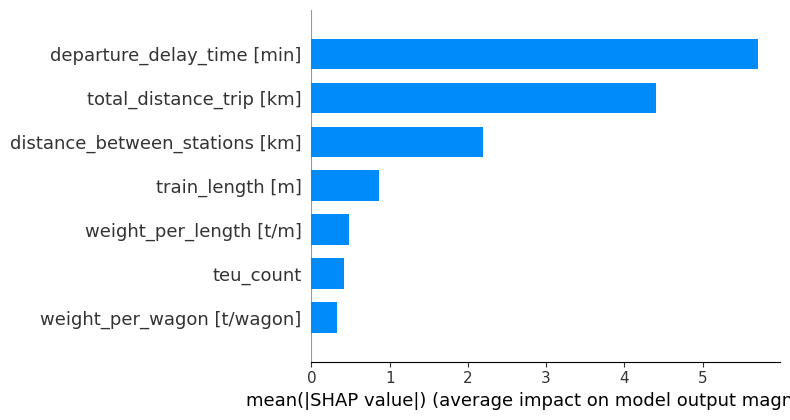

In [11]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
import shap
import matplotlib.pyplot as plt

# 1. Initialize the Base LightGBM Model
lgbm_base = lgb.LGBMRegressor(random_state=42, n_jobs=-1)

# 2. Define the Hyperparameter Grid for Random Search
# The paper tuned these parameters to optimize performance
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 50, 100],
    'max_depth': [-1, 10, 20],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 3. Perform Random Search with 5-Fold Cross Validation
print("Tuning LightGBM with Random Search (this might take a minute)...")
lgbm_random = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_grid,
    n_iter=15,          # Number of parameter settings that are sampled
    cv=5,               # 5-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Fit the random search model
lgbm_random.fit(X_train_scaled, y_train)

# 4. Get the Best Model and Predict
best_lgbm = lgbm_random.best_estimator_
print(f"Best Parameters found: {lgbm_random.best_params_}\n")

lgbm_preds = best_lgbm.predict(X_test_scaled)
evaluate_model("Tuned LightGBM", y_test, lgbm_preds)

# ==========================================
# STEP 5: SHAP Interpretability Layer
# ==========================================
# This matches the paper's methodology for explaining the predictions
print("Generating SHAP Feature Importance...")

# SHAP expects a DataFrame to keep feature names, so we convert the scaled array back
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test_scaled_df)

# Plot the Summary Plot (This will look similar to Figure 6 in the paper)
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar")

## LSTM

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Reshape data for LSTM [samples, time steps, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# 2. Build the LSTM Architecture
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2), # Dropout to prevent overfitting
    Dense(32, activation='relu'),
    Dense(1)      # Output layer for regression (predicting arrival delay)
])

# 3. Compile the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# 4. Train the model
print("Training LSTM...")
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# 5. Predict and Evaluate
lstm_preds = lstm_model.predict(X_test_lstm).flatten()
evaluate_model("LSTM", y_test, lstm_preds)

Training LSTM...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


386/386 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 1208.3673 - val_loss: 176.9238
Epoch 2/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 175.5349 - val_loss: 131.9968
Epoch 3/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 151.1946 - val_loss: 122.3865
Epoch 4/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 142.1288 - val_loss: 117.1002
Epoch 5/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 135.7745 - val_loss: 112.5419
Epoch 6/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 131.1926 - val_loss: 108.1460
Epoch 7/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 123.3151 - val_loss: 102.0664
Epoch 8/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 119.5947 - val_loss: 98.1035
Epoch 9/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 114.9453 - val_loss: 94.9696
Epoch 10/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 112.1012 - val_loss: 91.5425
Epoch 11/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 107.3395 - val_loss: 88.5250
Epoch 12/20
386/386 